In [1]:
import numpy as np
import matplotlib.pyplot as plt

# Question 7

In this problem, we will implement a function to compute the EOC given a vector of step sizes $h_k$ and a vector of errors $e_k$. We will then use it to experimentally verify the consistency order of various numerical methods for solving ODEs.

### Q7 (a)

Write a function `evolve(t0, y0, f, Phi, h, N)` that returns returns an approximate solution $u_n$, $n \in \{0, \dotsc, N \}$, using step size $h$ and $N$ steps, and the method given by the increment function $\Phi(t, y, f, h)$, for the initial value problem $$\large y'(t) = -\left( \frac{1}{10} + \cos(t) \right) y(t)^2, \qquad y(0) = 1,$$ which has the exact solution $y(t) = \dfrac{1}{1 + \frac{t}{10} + \sin t}$.

Use this function to compute the approximations, with both the Euler and Heun methods as increment functions. Plot the approximation against the exact solution for $N \in \{10, 100\}$, with $T = 10$, for both the forward Euler and Heun methods, in a single plot. Comment on your results.

In [2]:
def evolve(t0, y0, f, Phi, h, N):
    """Returns an array of N + 1 values approximating the IVP given by t0, y0, and f.

    `t0` is the initial time.
    `y0` is the initial y value.
    `f(t, y)` is the RHS of the ODE.
    `Phi(t, u, f, h)` is the increment function defining the one-step method to be used.
    `h` is the step size.
    `N` is the number of steps.
    """
    arr = [y0]

    for i in range(N):
        u = arr[-1]
        t = t0 + i * h
        u_next = u + h * Phi(t, u, f, h)

        arr.append(u_next)

    return np.array(arr)


def forwardEuler(t, u, f, h):
    return f(t, u)


def Heun(t, u, f, h):
    f_n = f(t, u)
    return (f_n + f(t + h, u + h * f_n)) / 2

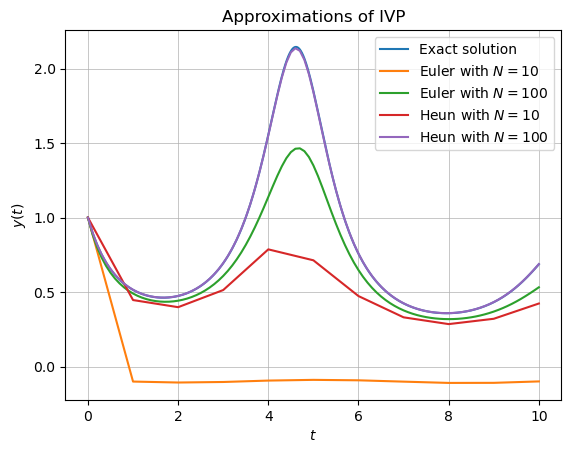

In [3]:
def plot_approximations_euler_heun():
    T = 10
    
    t = np.linspace(0, T, 1000)
    exact = 1 / (1 + t / 10 + np.sin(t))

    t_10 = np.linspace(0, T, 11)
    t_100 = np.linspace(0, T, 101)

    f = lambda t, y: -(1 / 10 + np.cos(t)) * y*y

    euler_10 = evolve(0, 1, f, forwardEuler, T / 10, 10)
    euler_100 = evolve(0, 1, f, forwardEuler, T / 100, 100)
    heun_10 = evolve(0, 1, f, Heun, T / 10, 10)
    heun_100 = evolve(0, 1, f, Heun, T / 100, 100)

    plt.plot(t, exact, label="Exact solution")
    plt.plot(t_10, euler_10, label="Euler with $N=10$")
    plt.plot(t_100, euler_100, label="Euler with $N=100$")
    plt.plot(t_10, heun_10, label="Heun with $N=10$")
    plt.plot(t_100, heun_100, label="Heun with $N=100$")
    
    plt.grid(True, which='both', linestyle='-', linewidth=0.5)
    
    plt.title(r"Approximations of IVP")
    plt.legend()
    plt.xlabel("$t$")
    plt.ylabel("$y(t)$")

    plt.show()
    plt.clf()
    plt.close()


plot_approximations_euler_heun()

Both approximations perform terribly with $N=10$, which gives large time steps of $h=1$. For $N=100$, the forward Euler method is okay, but the Heun method is incredibly close to the exact solution, making it by far the best option for approximation in this case.

### Q7 (b)

Write a function `lastError(Phi, h, N)` that returns $|u_N - y_N|$ (the difference between the approximation $u_n$ and the exact solution $y_n$ at the final step $n = N$, using step size $h$ and the method given by the increment function $\Phi(t, y, f, h)$). Do not output anything, just implement `lastError`.

In [4]:
def lastError(Phi, h, N):
    f = lambda t, y: -y * (1 / 10 + np.cos(t)) * y
    u = evolve(0, 1, f, Phi, h, N)
    t_N = h * N
    y_N = 1 / (1 + t_N / 10 + np.sin(t_N))
    return np.abs(u[-1] - y_N)

### Q7 (c)

Write a function `EOC(hs, errs)` which takes a vector of timesteps `hs` and a vector of errors `errs` to compute the experimental order of convergence as a vector. Given our definition in the lecture, we cannot compute the EOC for the first pair of timestep and error. Your function should therefore put a sensible value in its place, such as NaN. Do not output anything, just implement `EOC`.

In [5]:
def EOC(hs, errs):
    eocs = [np.inf / np.inf] # Start with NaN
    
    for i in range(1, min(len(hs), len(errs))):
        eocs.append(np.log(errs[i - 1] / errs[i]) / np.log(hs[i - 1] / hs[i]))

    return np.array(eocs)

### Q7 (d)

For the stepsizes $$\large h_k = \frac{T}{N_0 2^k}, \qquad k \in \{0, \dotsc, 10\},$$ (and therefore corresponding number of steps $N_k = N_0 2^k$), with $N_0 = 4$ and $T = 10$, provide a graphical evaluation of the errors (using `lastError`), comparing against their theoretical scaling, as well as a table of EOCs (using `EOC`). Do so for both the forward Euler method and the Heun method. Comment on your results.

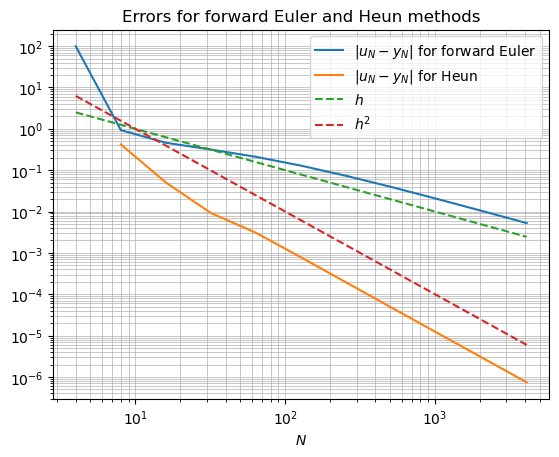

    Forward Euler
h	Error	EOC
--------------------
2.5	99	nan
1.2	0.93	6.7
0.62	0.46	1
0.31	0.32	0.54
0.16	0.21	0.59
0.078	0.13	0.71
0.039	0.073	0.82
0.02	0.039	0.9
0.0098	0.02	0.94
0.0049	0.01	0.97
0.0024	0.0053	0.98



         Heun
h	Error	 EOC
--------------------
2.5	1.6e+27	 nan
1.2	0.42	 92
0.62	0.05	 3.1
0.31	0.0092	 2.5
0.16	0.0031	 1.6
0.078	0.00077	 2
0.039	0.00019	 2
0.02	4.8e-05	 2
0.0098	1.2e-05	 2
0.0049	3e-06	 2
0.0024	7.4e-07	 2


In [6]:
def plot_errors_print_eoc_forward_euler_heun():
    N_0 = 4
    T = 10

    k = np.arange(0, 11)

    N = N_0 * 2**k
    h = T / N

    errors_euler = np.array(list(map(
        lambda i: lastError(forwardEuler, h[i], N[i]),
        range(len(k))
    )))
    errors_heun = np.array(list(map(
        lambda i: lastError(Heun, h[i], N[i]),
        range(len(k))
    )))

    plt.loglog(N, errors_euler, label=r"$|u_N - y_N|$ for forward Euler")
    plt.loglog(N[1:], errors_heun[1:], label=r"$|u_N - y_N|$ for Heun")
    plt.loglog(N, h, label="$h$", linestyle="dashed")
    plt.loglog(N, h**2, label="$h^2$", linestyle="dashed")
    
    plt.grid(True, which='both', linestyle='-', linewidth=0.5)
    
    plt.title(r"Errors for forward Euler and Heun methods")
    plt.legend()
    plt.xlabel("$N$")

    plt.show()
    plt.clf()
    plt.close()

    eocs_euler = EOC(h, errors_euler)
    print("    Forward Euler")
    print("h\tError\tEOC")
    print("--------------------")
    for i in range(len(h)):
        print(f"{h[i]:.2g}\t{errors_euler[i]:.2g}\t{eocs_euler[i]:.2g}")

    print("\n\n")
        
    eocs_heun = EOC(h, errors_heun)
    print("         Heun")
    print("h\tError\t EOC")
    print("--------------------")
    for i in range(len(h)):
        print(f"{h[i]:.2g}\t{errors_heun[i]:.2g}\t {eocs_heun[i]:.2g}")


plot_errors_print_eoc_forward_euler_heun()

Both the forward Euler and Heun methods have errors that scale as we would expect.

The case of $k=0$ for the Heun method has been deliberately excluded from the plot since the error is on the order of $10^{27}$.

# Question 8

In this problem we will implement the increment function for generic explicit Runge–Kutta methods, and consider so-called embedded methods.

### Q8 (a)

Write a function `explicitRK(t, u, f, h, A, b, c)` which implements the increment function for a generic explicit Runge–Kutta method with Butcher tableau $$\large \begin{array}{c|c}
c & A \\
\hline
& b^T
\end{array}\ \ :=\ \ \begin{array}{c|ccc}
c_1 & a_{11} & \cdots & a_{1s} \\
\vdots & \vdots & \ddots & \vdots \\
c_s & a_{s1} & \cdots & a_{ss} \\
\hline
& b_1 & \cdots & b_s \\
\end{array}$$ given by $A \in \mathbb{R}^{s \times s}$, $b \in \mathbb{R}^s$, and $c \in \mathbb{R}^s$, where $s$ is the number of stages. You may assume that $A$ is lower triangular with zero diagonal.

The easiest way to implement the method is to loop over stages, and at each stage compute the next $K$ from all previous $K$.

Use this function to implement the three methods $$\large \underbrace{\begin{array}{c|c}
0 & 0 \\
\hline
& 1
\end{array}}_\text{Forward Euler}
\qquad \underbrace{\begin{array}{c|cc}
0 & 0 & 0 \\
\frac{1}{2} & \frac{1}{2} & 0 \\
\hline
& 0 & 1
\end{array}}_\text{Explicit Midpoint}
\qquad \underbrace{\begin{array}{c|ccc}
0 & 0 & 0 & 0 \\
\frac{1}{2} & \frac{1}{2} & 0 & 0 \\
1 & -1 & 2 & 0 \\
\hline
& \frac{1}{6} & \frac{2}{3} & \frac{1}{6}
\end{array}}_\text{RK3}$$ which are of first, second, and third order respectively. Use your code and the parameters and IVP from the previous problem to plot the error at the last step, $|u_N - y_N|$ for the same $h_k$ and $N_k$, to graphically verify the order of your implementation. Comment on the observed orders in relation to the number of stages, and compare to what is possible in theory.

In [7]:
def explicitRK(t, u, f, h, A, b, c):
    """An increment function for explicit Runge--Kutta methods."""
    assert type(A) == np.ndarray, "A must be a NumPy array"
    assert type(b) == np.ndarray, "b must be a NumPy array"
    assert type(c) == np.ndarray, "c must be a NumPy array"

    (s,) = c.shape

    assert b.shape == (s,), "b and c must have the same length"
    assert A.shape == (s, s), "A must be a square matrix with the same side lengths as b and c"
    
    K = []
    for i in range(s):
        K_sum = 0
        for j in range(i): # We assume that A is lower triangular with zero diagonal
            K_sum += A[i][j] * K[j]

        K_i = f(t + c[i] * h, u + h * K_sum)
        K.append(K_i)

    return np.sum(b * np.array(K))

In [8]:
def wrapRK(A, b, c):
    """Given the data of a Butcher tableau, return an increment function compatible with `evolve`."""
    def Phi(t, u, f, h):
        return explicitRK(t, u, f, h, A, b, c)

    return Phi


forwardEulerRK = wrapRK(
    np.array([[0]]),
    np.array([1]),
    np.array([0])
)
explicitMidpoint = wrapRK(
    np.array([[0, 0], [1/2, 0]]),
    np.array([0, 1]),
    np.array([0, 1/2])
)
RK3 = wrapRK(
    np.array([[0, 0, 0], [1/2, 0, 0], [-1, 2, 0]]),
    np.array([1/6, 2/3, 1/6]),
    np.array([0, 1/2, 1])
)

/tmp/ipykernel_3825895/2034199295.py:2: RuntimeWarning: overflow encountered in scalar multiply
  f = lambda t, y: -y * (1 / 10 + np.cos(t)) * y


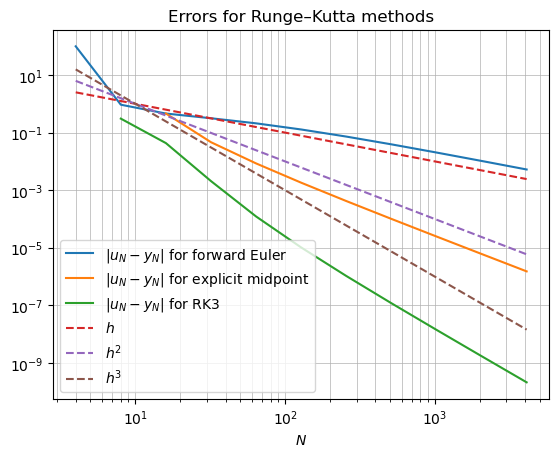

In [9]:
def plot_errors_rk_methods():
    N_0 = 4
    T = 10

    k = np.arange(0, 11)

    N = N_0 * 2**k
    h = T / N

    errors_euler = np.array(list(map(
        lambda i: lastError(forwardEulerRK, h[i], N[i]),
        range(len(k))
    )))
    errors_midpoint = np.array(list(map(
        lambda i: lastError(explicitMidpoint, h[i], N[i]),
        range(len(k))
    )))
    errors_rk3 = np.array(list(map(
        lambda i: lastError(RK3, h[i], N[i]),
        range(len(k))
    )))

    plt.loglog(N, errors_euler, label=r"$|u_N - y_N|$ for forward Euler")
    plt.loglog(N[2:], errors_midpoint[2:], label=r"$|u_N - y_N|$ for explicit midpoint")
    plt.loglog(N, errors_rk3, label=r"$|u_N - y_N|$ for RK3")
    plt.loglog(N, h, label="$h$", linestyle="dashed")
    plt.loglog(N, h**2, label="$h^2$", linestyle="dashed")
    plt.loglog(N, h**3, label="$h^3$", linestyle="dashed")
    
    plt.grid(True, which='both', linestyle='-', linewidth=0.5)
    
    plt.title(r"Errors for Runge–Kutta methods")
    plt.legend()
    plt.xlabel("$N$")

    plt.show()
    plt.clf()
    plt.close()


plot_errors_rk_methods()

The methods all scale with the order that we expect, and the line for the forward Euler method matches the line from the previous question, so we can be confident that the implementation is correct. We can observe that these Runge–Kutta methods have order equal to their stage count, and indeed this is the best possible order in theory when considering only explicit methods.

### Q8 (b)

One-step methods are well-suited to adaptively changing the stepsize $h$ depending on the problem: larger $h$ are generally more efficient but less accurate, so we want to pick a stepsize $h$ that adapts to the problem at hand. To do so, we want to estimate the truncation error on the fly, and adaptively change the stepsize to be below a certain error threshold.

This is made particularly easy by *embedded* Runge–Kutta methods, which are of the form $$\large \begin{array}{c|c}
c & A \\
\hline
& b^T \\
& \hat b^T
\end{array}$$ which defines two RK-methods with identical $A$ and $c$, but use either the provided $b$ or $\hat b$ respectively. Generally, the two methods are constructed to have order $p$ and $p + 1$, such that we can consider their difference as a first-order approximation of the truncation error $$\large \tau(h) = h \sum_{i=1}^s (\hat b_i - b_i) K_i.$$

Write a function `embeddedRK(t, u, f, h, A, b, bhat, c)` which implements the joint computation of the two increment functions for a generic embedded Runge–Kutta method with Butcher tableau given by $A \in \mathbb{R}^{s \times s}$, $b, \hat b, c \in \mathbb{R}^s$, where $s$ is the number of stages. The function is supposed to return two values, namely the evaluation of both increment functions of the embedded scheme. Additionally, write a function `embeddedEvolve(t0, y0, f, embeddedPhi, h, N)`, which returns both the approximation $u_n$, $n \in \{0, \dotsc, N\}$ (computed via the more accurate $\hat b$) as well as the local approximation of the truncation error $\tau_n$.

In a single plot, show the approximation $u_n$, estimated truncation error $\tau_n$ and the exact solution $y(t)$ against time for the above IVP for $N = 32$, $T = 10$, for the Heun–Euler method $$\large \begin{array}{c|cc}
0 \\
1 & 1 \\
\hline
& 1 & 0 \\
& \frac{1}{2} & \frac{1}{2}
\end{array}$$ With this plot, comment at what times an adaptive algorithm should increase or decrease the timestep.

In [10]:
def embeddedRK(t, u, f, h, A, b, bhat, c):
    pass # TODO


def embeddedEvolve(t0, y0, f, embeddedPhi, h, N):
    pass # TODO

In [11]:
# TODO: Plot approximation, truncation error, and exact solution

TODO: Comment

# Question 9

In this problem we will plot the region of absolute stability of Runge–Kutta methods. Write a function `getR(A, b, c)`, that for a Runge–Kutta method specified by $A$, $b$, $c$, returns the stability function `R(z)` as a function of a complex argument $z \in \mathbb{C}$. Use this function to plot the region of absolute stability of the RK3 method defined in **Q8**.

In [12]:
def getR(A, b, c):
    assert type(A) == np.ndarray, "A must be a NumPy array"
    assert type(b) == np.ndarray, "b must be a NumPy array"
    assert type(c) == np.ndarray, "c must be a NumPy array"

    (s,) = c.shape

    assert b.shape == (s,), "b and c must have the same length"
    assert A.shape == (s, s), "A must be a square matrix with the same side lengths as b and c"
    
    def R(z):
        return 1 + z * b.T @ np.linalg.inv(np.eye(s) - z * A) @ np.ones(s)

    return R

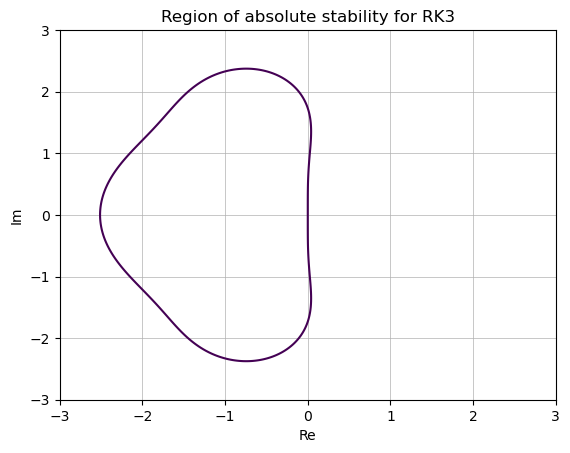

In [13]:
def plot_region_absolute_stability():
    R = getR(
        np.array([[0, 0, 0], [1/2, 0, 0], [-1, 2, 0]]),
        np.array([1/6, 2/3, 1/6]),
        np.array([0, 1/2, 1])
    )

    x = np.linspace(-3, 3, 250)
    y = np.linspace(-3, 3, 250)
    X, Y = np.meshgrid(x, y)
    Z = X + Y * 1j
    RZ = np.vectorize(lambda z: np.abs(R(z)))(Z)
    
    plt.contour(X, Y, RZ, [1])
    
    plt.grid(True, which='both', linestyle='-', linewidth=0.5)
    
    plt.title(r"Region of absolute stability for RK3")
    plt.xlabel("Re")
    plt.ylabel("Im")

    plt.show()
    plt.clf()
    plt.close()


plot_region_absolute_stability()